# BFP Weight Grouping Permutation Experiment

이 노트북은 **weight-only BFP grouping permutation**이 의미가 있는지 빠르게 확인하기 위한 실험 코드다.

핵심 아이디어는 실제 matmul의 channel 순서를 바꾸지 않고, weight를 BFP quantize할 때만 column 순서를 바꿔서 block을 만든 뒤 다시 원래 순서로 복구하는 것이다.

```text
W_perm   = W[:, perm]
Wq_perm  = BFP(W_perm)
Wq       = Wq_perm[:, inv_perm]
y        = x @ Wq.T
```

따라서 이 실험은 runtime activation permutation 없이, **offline weight quantization grouping**만 비교한다.

비교하는 grouping:

- `contiguous`: 현재처럼 연속된 channel 32개를 한 block으로 묶음
- `round_robin_balance`: 큰 channel score를 여러 group에 분산
- `sorted_bucket`: 비슷한 magnitude channel끼리 같은 group에 묶음

BFP는 shared exponent 때문에 outlier를 섞는 게 항상 좋은지 확실하지 않다. 그래서 두 permutation을 모두 비교해서 quantization error로 판단한다.

In [1]:
from pathlib import Path
import math
import sys

import torch
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoConfig, AutoModelForCausalLM

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "bfp_refactor").exists():
    # If the notebook is launched from bfp_refactor/notebooks, move to repo root.
    REPO_ROOT = Path.cwd().parents[1]
sys.path.insert(0, str(REPO_ROOT))

torch.set_grad_enabled(False)
print("repo root:", REPO_ROOT)

repo root: /home1/irteam/shmin/SpinBFP/SpinQuant


In [2]:
# ===== User config =====
MODEL = "meta-llama/Llama-2-7b-hf"
EXPERIMENT_DIR = "/home/irteam/shmin/SpinBFP/SpinQuant/bfp_runs/Llama-2-7b-hf"
ROTATION_PATH = None  # None이면 EXPERIMENT_DIR에서 R_{W}_{A}_{KV}_{had}.bin 자동 탐색
ACCESS_TOKEN = None

W_BITS = 3
A_BITS = 3
KV_BITS = 3
GROUP_SIZE = 32
W_DOWN_HAD_GROUP_SIZE = -1
QK_HAD_GROUP_SIZE = -1

# 분석할 단일 module
LAYER_IDX = 0
MODULE_NAME = "q_proj"  # llama: q_proj,k_proj,v_proj,o_proj,gate_proj,up_proj,down_proj

# 전체 sweep 옵션
RUN_FULL_SWEEP = True
MAX_LAYERS = 4  # RUN_FULL_SWEEP=True일 때 None이면 전체 layer
SELECTED_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]

DTYPE = "fp16"  # fp16, bf16, fp32, auto
ROTATION_COMPUTE_DTYPE = "fp64"  # fp64 or fp32
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BFP_EXPONENT_ROUNDING = "floor"  # floor or ceil

print("device:", DEVICE)

device: cuda


In [3]:
def hadamard_type(group_size):
    return "B" if group_size is not None and group_size > 0 else "F"


def expected_rotation_filename():
    suffix = hadamard_type(W_DOWN_HAD_GROUP_SIZE) + hadamard_type(QK_HAD_GROUP_SIZE)
    return f"R_{W_BITS}_{A_BITS}_{KV_BITS}_{suffix}.bin"


def find_rotation_path():
    if ROTATION_PATH is not None:
        return Path(ROTATION_PATH)
    exp = Path(EXPERIMENT_DIR)
    expected = exp / expected_rotation_filename()
    if expected.exists():
        return expected
    matches = sorted(p for p in exp.glob("R_*_*_*_*.bin") if p.name.count("_") == 4)
    if len(matches) == 1:
        return matches[0]
    raise FileNotFoundError(f"rotation file not found: {expected}; candidates={matches}")


def resolve_dtype(dtype_arg, model_name, token=None):
    if dtype_arg == "fp16":
        return torch.float16
    if dtype_arg == "bf16":
        return torch.bfloat16
    if dtype_arg == "fp32":
        return torch.float32
    cfg = AutoConfig.from_pretrained(model_name, token=token)
    config_dtype = getattr(cfg, "torch_dtype", None)
    if isinstance(config_dtype, str):
        config_dtype = config_dtype.replace("torch.", "")
        if config_dtype in ["bfloat16", "bf16"]:
            return torch.bfloat16
        if config_dtype in ["float32", "fp32"]:
            return torch.float32
        if config_dtype in ["float16", "fp16", "half"]:
            return torch.float16
    if config_dtype in [torch.float16, torch.bfloat16, torch.float32]:
        return config_dtype
    return torch.float16


def resolve_compute_dtype(dtype_arg):
    return torch.float32 if dtype_arg == "fp32" else torch.float64


rotation_path = find_rotation_path()
model_dtype = resolve_dtype(DTYPE, MODEL, token=ACCESS_TOKEN)
compute_dtype = resolve_compute_dtype(ROTATION_COMPUTE_DTYPE)
print("rotation_path:", rotation_path)
print("model_dtype:", model_dtype, "rotation_compute_dtype:", compute_dtype)

rotation_path: /home/irteam/shmin/SpinBFP/SpinQuant/bfp_runs/Llama-2-7b-hf/R_3_3_3_FF.bin
model_dtype: torch.float16 rotation_compute_dtype: torch.float64


In [4]:
# ===== BFP quantization identical to bfp_refactor/bfp_llama/bfp.py semantics =====
def _round_log2(x):
    log2_x = torch.log2(x)
    if BFP_EXPONENT_ROUNDING == "ceil":
        return torch.ceil(log2_x)
    return torch.floor(log2_x)


def _mantissa_denominator(maxq):
    if BFP_EXPONENT_ROUNDING == "ceil":
        return maxq + 1
    return (maxq + 1) / 2


def _scale_from_absmax(xmax):
    xmax_f = xmax.float()
    nonzero = xmax_f > 0
    safe = torch.where(nonzero, xmax_f, torch.ones_like(xmax_f))
    scale = torch.pow(2.0, _round_log2(safe))
    scale = torch.where(nonzero, scale, torch.ones_like(scale))
    return scale.to(dtype=xmax.dtype)


def bfp_quant_dequant(x, bits=W_BITS, group_size=GROUP_SIZE):
    if bits >= 16:
        return x
    assert bits >= 2
    assert x.shape[-1] % group_size == 0, (x.shape, group_size)
    x_dtype = x.dtype
    maxq = (2 ** bits) - 1
    denom = _mantissa_denominator(maxq)
    shape = x.shape
    grouped = x.reshape(*shape[:-1], shape[-1] // group_size, group_size)
    absmax = torch.amax(torch.abs(grouped), dim=-1, keepdim=True)
    scale = _scale_from_absmax(absmax)
    q = torch.clamp(torch.round(torch.abs(grouped) / scale * denom), 0, maxq)
    q = q * torch.sign(grouped)
    return (scale * (q / denom)).reshape(shape).to(x_dtype)


def group_absmax(weight, group_size=GROUP_SIZE):
    grouped = weight.reshape(weight.shape[0], weight.shape[-1] // group_size, group_size)
    return grouped.abs().float().amax(dim=-1)


def quant_error(weight, qweight):
    w = weight.float()
    qw = qweight.float()
    err = qw - w
    denom = torch.sum(w * w).clamp_min(1e-12)
    return {
        "mse": torch.mean(err * err).item(),
        "rel_mse": (torch.sum(err * err) / denom).item(),
        "mae": torch.mean(err.abs()).item(),
        "max_abs_err": err.abs().max().item(),
    }


def summarize_groups(values):
    v = values.flatten().float()
    qs = torch.quantile(v, torch.tensor([0.0, 0.5, 0.9, 0.95, 0.99, 1.0], device=v.device))
    return {
        "group_absmax_mean": v.mean().item(),
        "group_absmax_std": v.std(unbiased=False).item(),
        "group_absmax_cv": (v.std(unbiased=False) / v.mean().clamp_min(1e-12)).item(),
        "group_absmax_min": qs[0].item(),
        "group_absmax_q50": qs[1].item(),
        "group_absmax_q90": qs[2].item(),
        "group_absmax_q95": qs[3].item(),
        "group_absmax_q99": qs[4].item(),
        "group_absmax_max": qs[5].item(),
    }

In [5]:
def identity_perm(n, device):
    return torch.arange(n, device=device)


def round_robin_balance_perm(score, group_size=GROUP_SIZE):
    """Distribute high-score channels across groups."""
    n = score.numel()
    assert n % group_size == 0
    num_groups = n // group_size
    order = torch.argsort(score.float(), descending=True)
    groups = [[] for _ in range(num_groups)]
    for rank, idx in enumerate(order.tolist()):
        groups[rank % num_groups].append(idx)
    perm = torch.tensor([idx for group in groups for idx in group], device=score.device, dtype=torch.long)
    return perm


def sorted_bucket_perm(score, group_size=GROUP_SIZE):
    """Group similar-score channels together."""
    return torch.argsort(score.float(), descending=True)


def interleave_low_high_perm(score, group_size=GROUP_SIZE):
    """A conservative variant: mix high and low within each group."""
    n = score.numel()
    assert n % group_size == 0
    order = torch.argsort(score.float(), descending=True).tolist()
    hi = order[: math.ceil(n / 2)]
    lo = list(reversed(order[math.ceil(n / 2):]))
    mixed = []
    while hi or lo:
        if hi:
            mixed.append(hi.pop(0))
        if lo:
            mixed.append(lo.pop(0))
    return torch.tensor(mixed, device=score.device, dtype=torch.long)


def inverse_perm(perm):
    inv = torch.empty_like(perm)
    inv[perm] = torch.arange(perm.numel(), device=perm.device)
    return inv


def permuted_bfp_weight(weight, perm, bits=W_BITS, group_size=GROUP_SIZE):
    inv = inverse_perm(perm)
    wp = weight.index_select(-1, perm)
    wq_perm = bfp_quant_dequant(wp, bits=bits, group_size=group_size)
    return wq_perm.index_select(-1, inv)


def score_input_channels(weight, mode="max_abs"):
    w = weight.float().abs()
    if mode == "max_abs":
        return w.amax(dim=0)
    if mode == "mean_abs":
        return w.mean(dim=0)
    if mode == "p99_abs":
        return torch.quantile(w, 0.99, dim=0)
    raise ValueError(mode)


def evaluate_grouping_strategy(weight, perm, name, bits=W_BITS, group_size=GROUP_SIZE):
    if perm is None:
        arranged = weight
        qweight = bfp_quant_dequant(weight, bits=bits, group_size=group_size)
    else:
        arranged = weight.index_select(-1, perm)
        qweight = permuted_bfp_weight(weight, perm, bits=bits, group_size=group_size)
    row = {"strategy": name}
    row.update(summarize_groups(group_absmax(arranged, group_size)))
    row.update(quant_error(weight, qweight))
    return row, qweight, arranged

In [6]:
def apply_r2_to_weight(weight, r2, transpose, compute_dtype):
    if r2 is None:
        return weight
    had_dim = r2.shape[0]
    if transpose:
        shape = weight.shape
        temp = weight.reshape(-1, shape[-1] // had_dim, had_dim)
        return (temp.to(compute_dtype) @ r2.to(compute_dtype)).reshape(shape).to(weight.dtype)
    wt = weight.t()
    shape = wt.shape
    temp = wt.reshape(-1, shape[-1] // had_dim, had_dim)
    return (temp.to(compute_dtype) @ r2.to(compute_dtype)).reshape(shape).t().to(weight.dtype)


def effective_weight_llama(weight, role, r1, r2, rotate=True, compute_dtype=torch.float64):
    if not rotate:
        return weight
    dtype = weight.dtype
    if role in ["q_proj", "k_proj", "gate_proj", "up_proj", "lm_head"]:
        weight = (weight.to(compute_dtype) @ r1.to(compute_dtype)).to(dtype)
    elif role in ["o_proj", "down_proj"]:
        weight = (r1.to(compute_dtype).t() @ weight.to(compute_dtype)).to(dtype)
    elif role == "v_proj":
        weight = (weight.to(compute_dtype) @ r1.to(compute_dtype)).to(dtype)
    if role == "v_proj":
        weight = apply_r2_to_weight(weight, r2, transpose=False, compute_dtype=compute_dtype)
    elif role == "o_proj":
        weight = apply_r2_to_weight(weight, r2, transpose=True, compute_dtype=compute_dtype)
    return weight


def effective_weight_opt(weight, role, r1, r2, rotate=True, compute_dtype=torch.float64):
    if not rotate:
        return weight
    dtype = weight.dtype
    if role in ["q_proj", "k_proj", "v_proj", "fc1", "lm_head"]:
        weight = (weight.to(compute_dtype) @ r1.to(compute_dtype)).to(dtype)
    elif role in ["out_proj", "fc2"]:
        weight = (r1.t().to(compute_dtype) @ weight.to(compute_dtype)).to(dtype)
    if role == "v_proj":
        weight = apply_r2_to_weight(weight, r2, transpose=False, compute_dtype=compute_dtype)
    elif role == "out_proj":
        weight = apply_r2_to_weight(weight, r2, transpose=True, compute_dtype=compute_dtype)
    return weight


def iter_llama_modules(model, include_lm_head=False):
    for layer_idx, layer in enumerate(model.model.layers):
        yield layer_idx, "q_proj", layer.self_attn.q_proj
        yield layer_idx, "k_proj", layer.self_attn.k_proj
        yield layer_idx, "v_proj", layer.self_attn.v_proj
        yield layer_idx, "o_proj", layer.self_attn.o_proj
        yield layer_idx, "gate_proj", layer.mlp.gate_proj
        yield layer_idx, "up_proj", layer.mlp.up_proj
        yield layer_idx, "down_proj", layer.mlp.down_proj
    if include_lm_head:
        yield "lm_head", "lm_head", model.lm_head


def iter_opt_modules(model, include_lm_head=False):
    for layer_idx, layer in enumerate(model.model.decoder.layers):
        yield layer_idx, "q_proj", layer.self_attn.q_proj
        yield layer_idx, "k_proj", layer.self_attn.k_proj
        yield layer_idx, "v_proj", layer.self_attn.v_proj
        yield layer_idx, "out_proj", layer.self_attn.out_proj
        yield layer_idx, "fc1", layer.fc1
        yield layer_idx, "fc2", layer.fc2
    if include_lm_head:
        yield "lm_head", "lm_head", model.lm_head


def r2_key(model_type, layer_idx):
    if model_type == "llama":
        return f"model.layers.{layer_idx}.self_attn.R2"
    if model_type == "opt":
        return f"model.decoder.layers.{layer_idx}.self_attn.R2"
    raise ValueError(model_type)

In [7]:
print("Loading config/rotation/model...")
hf_config = AutoConfig.from_pretrained(MODEL, token=ACCESS_TOKEN)
rotations = torch.load(rotation_path, map_location="cpu")
r1 = rotations["R1"].to(device=DEVICE)

model = AutoModelForCausalLM.from_pretrained(
    MODEL,
    config=hf_config,
    torch_dtype=model_dtype,
    low_cpu_mem_usage=True,
    token=ACCESS_TOKEN,
).eval().to(DEVICE)

if hf_config.model_type == "llama":
    module_iter = iter_llama_modules
    effective_weight = effective_weight_llama
elif hf_config.model_type == "opt":
    module_iter = iter_opt_modules
    effective_weight = effective_weight_opt
else:
    raise ValueError(f"Unsupported model_type={hf_config.model_type}")

print("model_type:", hf_config.model_type)
print("hidden_size:", getattr(hf_config, "hidden_size", None))

Loading config/rotation/model...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

model_type: llama
hidden_size: 4096


In [8]:
def get_module_weight(layer_idx, module_name):
    for li, name, linear in module_iter(model):
        if li == layer_idx and name == module_name:
            weight = linear.weight.detach().to(DEVICE)
            r2 = None
            key = r2_key(hf_config.model_type, layer_idx)
            if key in rotations:
                r2 = rotations[key].to(device=DEVICE)
            rotated = effective_weight(
                weight,
                module_name,
                r1,
                r2,
                rotate=True,
                compute_dtype=compute_dtype,
            )
            return weight, rotated
    raise KeyError((layer_idx, module_name))


weight, rotated = get_module_weight(LAYER_IDX, MODULE_NAME)
print("module:", LAYER_IDX, MODULE_NAME)
print("weight shape:", tuple(weight.shape), "rotated dtype:", rotated.dtype)
assert rotated.shape[-1] % GROUP_SIZE == 0

module: 0 q_proj
weight shape: (4096, 4096) rotated dtype: torch.float16


In [9]:
score = score_input_channels(rotated, mode="max_abs")
perms = {
    "contiguous": None,
    "round_robin_balance": round_robin_balance_perm(score, GROUP_SIZE),
    "sorted_bucket": sorted_bucket_perm(score, GROUP_SIZE),
    "interleave_low_high": interleave_low_high_perm(score, GROUP_SIZE),
}

rows = []
qweights = {}
arranged_weights = {}
for name, perm in perms.items():
    row, qw, arranged = evaluate_grouping_strategy(rotated, perm, name, bits=W_BITS, group_size=GROUP_SIZE)
    rows.append(row)
    qweights[name] = qw
    arranged_weights[name] = arranged

single_df = pd.DataFrame(rows).sort_values("rel_mse")
single_df

,strategy,group_absmax_mean,group_absmax_std,group_absmax_cv,group_absmax_min,group_absmax_q50,group_absmax_q90,group_absmax_q95,group_absmax_q99,group_absmax_max,mse,rel_mse,mae,max_abs_err
2,sorted_bucket,0.027762,0.014989,0.539910,0.004044,0.023880,0.046997,0.057007,0.080566,0.190063,0.000003,0.015602,0.001260,0.015625
3,interleave_low_high,0.028081,0.015435,0.549653,0.003607,0.024078,0.047455,0.057953,0.084473,0.190063,0.000003,0.016060,0.001274,0.015625
1,round_robin_balance,0.028095,0.015610,0.555626,0.003937,0.024048,0.047455,0.057953,0.085266,0.190063,0.000003,0.016145,0.001274,0.015625
0,contiguous,0.028151,0.015600,0.554152,0.003265,0.024109,0.047546,0.058014,0.085205,0.190063,0.000003,0.016199,0.001277,0.015625


In [10]:
# Lower rel_mse/mae is better. group_absmax_cv shows how uneven block exponents are.
display(single_df[[
    "strategy",
    "rel_mse",
    "mse",
    "mae",
    "max_abs_err",
    "group_absmax_mean",
    "group_absmax_cv",
    "group_absmax_q95",
    "group_absmax_q99",
    "group_absmax_max",
]])

,strategy,rel_mse,mse,mae,max_abs_err,group_absmax_mean,group_absmax_cv,group_absmax_q95,group_absmax_q99,group_absmax_max
2,sorted_bucket,0.015602,0.000003,0.001260,0.015625,0.027762,0.539910,0.057007,0.080566,0.190063
3,interleave_low_high,0.016060,0.000003,0.001274,0.015625,0.028081,0.549653,0.057953,0.084473,0.190063
1,round_robin_balance,0.016145,0.000003,0.001274,0.015625,0.028095,0.555626,0.057953,0.085266,0.190063
0,contiguous,0.016199,0.000003,0.001277,0.015625,0.028151,0.554152,0.058014,0.085205,0.190063


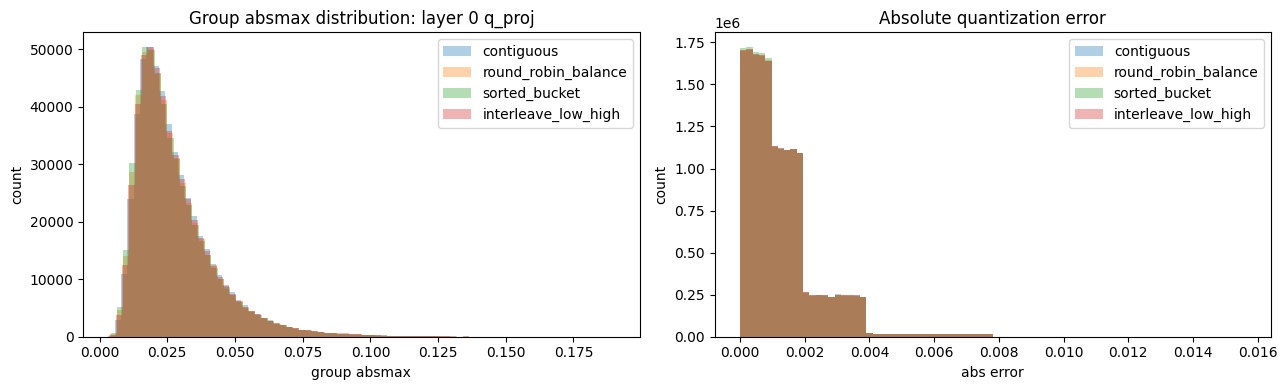

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, arranged in arranged_weights.items():
    vals = group_absmax(arranged, GROUP_SIZE).flatten().float().cpu()
    axes[0].hist(vals.numpy(), bins=80, alpha=0.35, label=name)
axes[0].set_title(f"Group absmax distribution: layer {LAYER_IDX} {MODULE_NAME}")
axes[0].set_xlabel("group absmax")
axes[0].set_ylabel("count")
axes[0].legend()

for name, qw in qweights.items():
    err = (qw.float() - rotated.float()).abs().flatten().cpu()
    axes[1].hist(err.numpy(), bins=80, alpha=0.35, label=name)
axes[1].set_title("Absolute quantization error")
axes[1].set_xlabel("abs error")
axes[1].set_ylabel("count")
axes[1].legend()
plt.tight_layout()
plt.show()

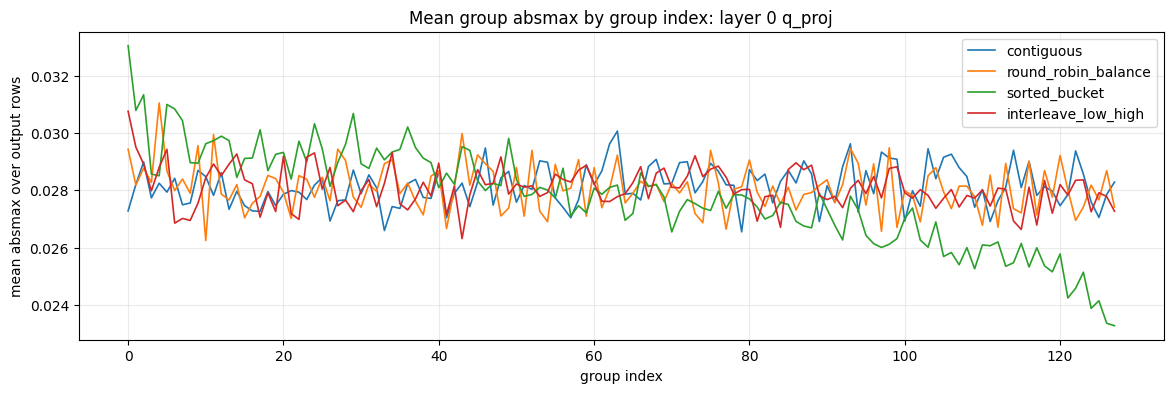

In [12]:
# Group index별 absmax를 순서대로 보기. permutation grouping 후에는 x축이 permuted group index다.
plot_df = []
for name, arranged in arranged_weights.items():
    g = group_absmax(arranged, GROUP_SIZE).mean(dim=0).float().cpu()
    for idx, val in enumerate(g.tolist()):
        plot_df.append({"strategy": name, "group_idx": idx, "mean_absmax_over_rows": val})
plot_df = pd.DataFrame(plot_df)

plt.figure(figsize=(14, 4))
for name in plot_df.strategy.unique():
    sub = plot_df[plot_df.strategy == name]
    plt.plot(sub.group_idx, sub.mean_absmax_over_rows, label=name, linewidth=1.2)
plt.title(f"Mean group absmax by group index: layer {LAYER_IDX} {MODULE_NAME}")
plt.xlabel("group index")
plt.ylabel("mean absmax over output rows")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## Full Sweep

아래 cell은 여러 layer/module에 대해 동일한 비교를 수행한다. 처음에는 `MAX_LAYERS=4` 정도로 빠르게 확인하고, 유망하면 전체 layer로 늘리는 것을 추천한다.

In [13]:
def evaluate_one_module(layer_idx, module_name, linear):
    weight = linear.weight.detach().to(DEVICE)
    if weight.shape[-1] % GROUP_SIZE != 0:
        return []
    r2 = None
    if isinstance(layer_idx, int):
        key = r2_key(hf_config.model_type, layer_idx)
        if key in rotations:
            r2 = rotations[key].to(device=DEVICE)
    rotated = effective_weight(weight, module_name, r1, r2, rotate=True, compute_dtype=compute_dtype)
    score = score_input_channels(rotated, mode="max_abs")
    perms = {
        "contiguous": None,
        "round_robin_balance": round_robin_balance_perm(score, GROUP_SIZE),
        "sorted_bucket": sorted_bucket_perm(score, GROUP_SIZE),
        "interleave_low_high": interleave_low_high_perm(score, GROUP_SIZE),
    }
    out = []
    for strategy, perm in perms.items():
        row, _, _ = evaluate_grouping_strategy(rotated, perm, strategy, bits=W_BITS, group_size=GROUP_SIZE)
        row.update({
            "layer": layer_idx,
            "module": module_name,
            "shape": "x".join(map(str, weight.shape)),
        })
        out.append(row)
    return out


if RUN_FULL_SWEEP:
    all_rows = []
    for layer_idx, module_name, linear in module_iter(model):
        if isinstance(layer_idx, int) and MAX_LAYERS is not None and layer_idx >= MAX_LAYERS:
            continue
        if SELECTED_MODULES is not None and module_name not in SELECTED_MODULES:
            continue
        rows = evaluate_one_module(layer_idx, module_name, linear)
        all_rows.extend(rows)
        print("done", layer_idx, module_name)
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    sweep_df = pd.DataFrame(all_rows)
else:
    sweep_df = pd.DataFrame()

sweep_df.head()

done 0 q_proj
done 0 k_proj
done 0 v_proj
done 0 o_proj
done 0 gate_proj
done 0 up_proj
done 0 down_proj
done 1 q_proj
done 1 k_proj
done 1 v_proj
done 1 o_proj
done 1 gate_proj
done 1 up_proj
done 1 down_proj
done 2 q_proj
done 2 k_proj
done 2 v_proj
done 2 o_proj
done 2 gate_proj
done 2 up_proj
done 2 down_proj
done 3 q_proj
done 3 k_proj
done 3 v_proj
done 3 o_proj
done 3 gate_proj
done 3 up_proj
done 3 down_proj


,strategy,group_absmax_mean,group_absmax_std,group_absmax_cv,group_absmax_min,group_absmax_q50,group_absmax_q90,group_absmax_q95,group_absmax_q99,group_absmax_max,mse,rel_mse,mae,max_abs_err,layer,module,shape
0,contiguous,0.028151,0.015600,0.554152,0.003265,0.024109,0.047546,0.058014,0.085205,0.190063,0.000003,0.016199,0.001277,0.015625,0,q_proj,4096x4096
1,round_robin_balance,0.028095,0.015610,0.555626,0.003937,0.024048,0.047455,0.057953,0.085266,0.190063,0.000003,0.016145,0.001274,0.015625,0,q_proj,4096x4096
2,sorted_bucket,0.027762,0.014989,0.539910,0.004044,0.023880,0.046997,0.057007,0.080566,0.190063,0.000003,0.015602,0.001260,0.015625,0,q_proj,4096x4096
3,interleave_low_high,0.028081,0.015435,0.549653,0.003607,0.024078,0.047455,0.057953,0.084473,0.190063,0.000003,0.016060,0.001274,0.015625,0,q_proj,4096x4096
4,contiguous,0.032688,0.015227,0.465828,0.004040,0.029877,0.051880,0.060638,0.083435,0.193726,0.000004,0.016174,0.001481,0.015625,0,k_proj,4096x4096


In [14]:
if RUN_FULL_SWEEP and not sweep_df.empty:
    pivot = sweep_df.pivot_table(index=["layer", "module"], columns="strategy", values="rel_mse")
    base = pivot["contiguous"]
    improvement = (base.to_frame("contiguous_rel_mse")
                   .join(((base.values[:, None] - pivot) / base.values[:, None]).add_suffix("_rel_improve")))
    display(improvement.sort_values("sorted_bucket_rel_improve", ascending=False).head(30))

    summary = sweep_df.groupby("strategy")[["rel_mse", "mae", "max_abs_err", "group_absmax_cv"]].mean().sort_values("rel_mse")
    display(summary)

contiguous_rel_mse  contiguous_rel_improve  \
layer module                                                  
0     q_proj               0.016199                     0.0   
      k_proj               0.016174                     0.0   
1     gate_proj            0.015866                     0.0   
0     gate_proj            0.016954                     0.0   
1     up_proj              0.016482                     0.0   
0     v_proj               0.016051                     0.0   
2     q_proj               0.016132                     0.0   
1     k_proj               0.016378                     0.0   
3     k_proj               0.016428                     0.0   
      q_proj               0.016648                     0.0   
0     down_proj            0.016773                     0.0   
1     v_proj               0.016620                     0.0   
3     v_proj               0.017473                     0.0   
2     k_proj               0.015998                     0.0   
3     down_proj            0.016119                     0.0   
      gate_proj            0.015298                     0.0   
1     q_proj               0.016240                     0.0   
2     gate_proj            0.015381                     0.0   
1     down_proj            0.016277                     0.0   
3     up_proj              0.016092                     0.0   
0     up_proj              0.017071                     0.0   
2     down_proj            0.016147                     0.0   
      up_proj              0.016215                     0.0   
      v_proj               0.017597                     0.0   
3     o_proj               0.017355                     0.0   
2     o_proj               0.017469                     0.0   
1     o_proj               0.015755                     0.0   
0     o_proj               0.016392                     0.0   

                 interleave_low_high_rel_improve  \
layer module                                       
0     q_proj                            0.008547   
      k_proj                            0.008655   
1     gate_proj                         0.004812   
0     gate_proj                         0.002510   
1     up_proj                           0.002626   
0     v_proj                           -0.000014   
2     q_proj                            0.000474   
1     k_proj                            0.000605   
3     k_proj                            0.000267   
      q_proj                           -0.001462   
0     down_proj                         0.000151   
1     v_proj                            0.000574   
3     v_proj                            0.000986   
2     k_proj                           -0.001518   
3     down_proj                         0.000371   
      gate_proj                         0.000889   
1     q_proj                           -0.002013   
2     gate_proj                         0.000366   
1     down_proj                         0.000043   
3     up_proj                           0.000213   
0     up_proj                          -0.000303   
2     down_proj                        -0.000207   
      up_proj                           0.000076   
      v_proj                           -0.000458   
3     o_proj                           -0.025846   
2     o_proj                           -0.020242   
1     o_proj                           -0.332718   
0     o_proj                           -0.254913   

                 round_robin_balance_rel_improve  sorted_bucket_rel_improve  
layer module                                                                 
0     q_proj                            0.003335                   0.036844  
      k_proj                            0.004010                   0.026232  
1     gate_proj                        -0.000719                   0.007711  
0     gate_proj                         0.000624                   0.004015  
1     up_proj                          -0.000521                   0.003102  
0     v_proj       

,rel_mse,mae,max_abs_err,group_absmax_cv
strategy,,,,
sorted_bucket,0.016385,0.001799,0.015994,0.319644
contiguous,0.016414,0.001800,0.015972,0.322576
interleave_low_high,0.016764,0.001812,0.015982,0.311726
round_robin_balance,0.016985,0.001817,0.016062,0.310311


In [29]:
# Optional: save sweep results
if RUN_FULL_SWEEP and not sweep_df.empty:
    out_dir = Path(EXPERIMENT_DIR) / "weight_group_permutation"
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"weight_group_perm_W{W_BITS}_G{GROUP_SIZE}.csv"
    sweep_df.to_csv(out_path, index=False)
    print("saved:", out_path)

## 해석 가이드

- `rel_mse`가 낮은 strategy가 weight BFP quantization 관점에서 더 좋다.
- `round_robin_balance`가 좋아지면 “outlier를 group 간에 분산”하는 방향이 유효한 것이다.
- `sorted_bucket`이 좋아지면 “비슷한 magnitude끼리 묶어서 shared exponent 낭비를 줄이는” 방향이 더 맞는 것이다.
- 둘 다 `contiguous`보다 별 차이가 없으면, weight-only grouping permutation은 contribution으로 약할 가능성이 높다.
- 이 노트북은 weight-only라서 activation/KV online permutation 비용은 포함하지 않는다.

In [31]:
sweep_df.head()

""
